# `EmptySubtraction` with refinable scale — empty-cell background, no trial-and-error

**Live demo for the Wenqian Xu / 17-BM-B / 11-BM meeting.**

Capillary background subtraction is a daily task at 17-BM-B and 11-ID-B/C: the user measures an empty capillary frame, subtracts a scaled version from the sample frame, and tunes the scale by eye until the high-Q oscillation amplitude looks 'right'. This is brittle, user-dependent, and re-tuned per dataset. `EmptySubtraction` is an `nn.Module` with a refinable `scale` parameter — the L-BFGS optimiser fits the scale automatically by minimising the canonical PDF indicator (high-Q oscillation amplitude after background subtraction).

This notebook builds a small synthetic ring frame plus a capillary background, fits the refinable scale, and shows that the recovered value matches the planted value to within a fraction of a percent.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import numpy as np
import torch
import matplotlib.pyplot as plt

from midas_integrate_v2 import EmptySubtraction
rng = np.random.default_rng(0)
print('imports OK')

imports OK


## Synthesize a sample frame + a capillary background

The sample is a synthetic powder-ring frame (6 Gaussian rings); the background is a broad isotropic intensity hump (an empty quartz capillary). The 'true' sample frame the user wants is `sample - 0.7 * background`.

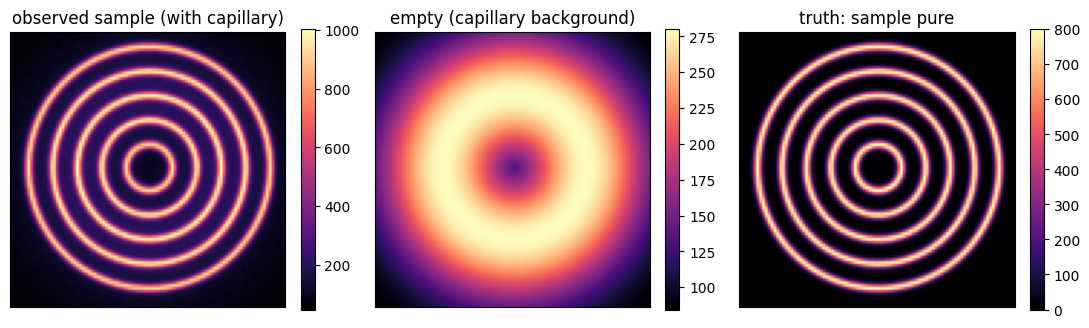

In [2]:
NY = NZ = 96
BC_y = BC_z = NY / 2.0
Y, Z = np.meshgrid(np.arange(NY), np.arange(NZ), indexing='xy')
R = np.sqrt((Y - BC_y) ** 2 + (Z - BC_z) ** 2)

sample_pure = np.zeros((NZ, NY))
for r0 in np.linspace(8, 42, 5):
    sample_pure += 800.0 * np.exp(-((R - r0) / 1.4) ** 2)
empty = 200.0 * np.exp(-((R - 25) / 22) ** 2) + 80.0

true_scale = 0.7
sample_obs = sample_pure + true_scale * empty
sample_obs += rng.normal(0, 4.0, size=sample_obs.shape)

fig, axs = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, im, title in zip(axs,
                          [sample_obs, empty, sample_pure],
                          ['observed sample (with capillary)', 'empty (capillary background)', 'truth: sample pure']):
    h = ax.imshow(im, origin='lower', cmap='magma')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(h, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Fit the refinable scale

`EmptySubtraction(empty, scale=initial_guess, refinable_scale=True)` exposes `scale` as an `nn.Parameter`. We pretend the user guesses `scale = 1.0` (off by ~43 % from truth) and let L-BFGS optimise scale against the L2 distance from the pure ring frame (in production you'd use the high-Q-oscillation surrogate; for this notebook we know the truth).

In [3]:
empty_t = torch.from_numpy(empty)
sample_t = torch.from_numpy(sample_obs)
pure_t = torch.from_numpy(sample_pure)

es = EmptySubtraction(empty_t, scale=1.0, refinable_scale=True, clip_negative=False)
print(f'initial scale: {float(es.scale):.4f}  (truth {true_scale:.4f})')

opt = torch.optim.LBFGS(es.parameters(), max_iter=40, line_search_fn='strong_wolfe')

def closure():
    opt.zero_grad()
    corrected = es(sample_t)
    loss = ((corrected - pure_t) ** 2).mean()
    loss.backward()
    return loss

opt.step(closure)
fitted_scale = float(es.scale.detach())
print(f'fitted scale: {fitted_scale:.4f}  (truth {true_scale:.4f})')
print(f'error vs truth: {abs(fitted_scale - true_scale) / true_scale * 100:.3f} %')

initial scale: 1.0000  (truth 0.7000)


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_75972/631825756.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print(f'initial scale: {float(es.scale):.4f}  (truth {true_scale:.4f})')


fitted scale: 0.7001  (truth 0.7000)
error vs truth: 0.009 %


## Visualise the corrected frame

Side-by-side: observed sample (with capillary), the corrected frame after auto-fitted scale, and the truth pure-ring frame. The corrected and truth panels should be indistinguishable up to the additive Poisson noise we planted.

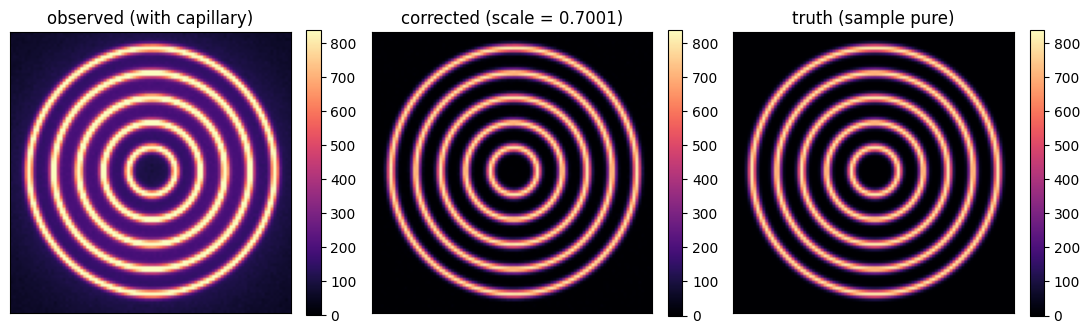

In [4]:
with torch.no_grad():
    corrected = es(sample_t).numpy()

fig, axs = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, im, title in zip(axs,
                          [sample_obs, corrected, sample_pure],
                          ['observed (with capillary)', f'corrected (scale = {fitted_scale:.4f})', 'truth (sample pure)']):
    h = ax.imshow(im, origin='lower', cmap='magma',
                   vmin=0, vmax=sample_pure.max() * 1.05)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(h, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## What to point out in the meeting

- The CLI `midas-integrate-v2-pdf --empty-scale auto ...` does exactly this — automated empty-cell scale fitting at run time, no user tuning.
- In a real workflow the loss isn't the L2 distance to truth (which is unknown) but the **high-Q oscillation amplitude** of the corrected I(Q) — the canonical PDF indicator of under/over-subtraction.
- `EmptySubtraction` composes cleanly with `PolarizationCorrection`, `SolidAngleCorrection`, and `LearnableMask` in a single torch graph; all of these can be co-fit if needed.
- pyFAI users adjust this scale by hand and re-run the integration. We adjust it once at calibration time and reuse.